# Lab 2: Cats vs Dogs

In this lab, you will train a convolutional neural network to classify an image 
into one of two classes: "cat" or "dog". The code for the neural networks 
you train will be written for you, and you are not (yet!) expected
to understand all provided code. However, by the end of the lab,
you should be able to:

1. Understand at a high level the training loop for a machine learning model.
2. Understand the distinction between training, validation, and test data.
3. The concepts of overfitting and underfitting.
4. Investigate how different hyperparameters, such as learning rate and batch size, affect the success of training.
5. Compare an ANN (aka Multi-Layer Perceptron) with a CNN.

### What to submit

Submit a PDF file containing all your code, outputs, and write-up
from parts 1-5. You can produce a PDF of your Google Colab file by
going to **File > Print** and then save as PDF. The Colab instructions
has more information.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission. 

With Colab, you can export a PDF file using the menu option
`File -> Print` and save as PDF file. **Adjust the scaling to ensure that the text is not cutoff at the margins.**

## Colab Link

Include a link to your colab file here

Colab Link: 

In [14]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms


## Part 0. Helper Functions

We will be making use of the following helper functions. You will be asked to look
at and possibly modify some of these, but you are not expected to understand all of them.

You should look at the function names and read the docstrings. If you are curious, come back and explore the code *after* making some progress on the lab.

In [15]:
###############################################################################
# Data Loading

def get_relevant_indices(dataset, classes, target_classes):
    """ Return the indices for datapoints in the dataset that belongs to the
    desired target classes, a subset of all possible classes.

    Args:
        dataset: Dataset object
        classes: A list of strings denoting the name of each class
        target_classes: A list of strings denoting the name of desired classes
                        Should be a subset of the 'classes'
    Returns:
        indices: list of indices that have labels corresponding to one of the
                 target classes
    """
    indices = []
    for i in range(len(dataset)):
        # Check if the label is in the target classes
        label_index = dataset[i][1] # ex: 3
        label_class = classes[label_index] # ex: 'cat'
        if label_class in target_classes:
            indices.append(i)
    return indices

def get_data_loader(target_classes, batch_size):
    """ Loads images of cats and dogs, splits the data into training, validation
    and testing datasets. Returns data loaders for the three preprocessed datasets.

    Args:
        target_classes: A list of strings denoting the name of the desired
                        classes. Should be a subset of the argument 'classes'
        batch_size: A int representing the number of samples per batch
    
    Returns:
        train_loader: iterable training dataset organized according to batch size
        val_loader: iterable validation dataset organized according to batch size
        test_loader: iterable testing dataset organized according to batch size
        classes: A list of strings denoting the name of each class
    """

    classes = ('plane', 'car', 'bird', 'cat',
               'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
    ########################################################################
    # The output of torchvision datasets are PILImage images of range [0, 1].
    # We transform them to Tensors of normalized range [-1, 1].
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    # Load CIFAR10 training data
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_indices = get_relevant_indices(trainset, classes, target_classes)
    
    # Split into train and validation
    np.random.seed(1000) # Fixed numpy random seed for reproducible shuffling
    np.random.shuffle(relevant_indices)
    split = int(len(relevant_indices) * 0.8) #split at 80%
    
    # split into training and validation indices
    relevant_train_indices, relevant_val_indices = relevant_indices[:split], relevant_indices[split:]  
    train_sampler = SubsetRandomSampler(relevant_train_indices)
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                               num_workers=1, sampler=train_sampler)
    val_sampler = SubsetRandomSampler(relevant_val_indices)
    val_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                              num_workers=1, sampler=val_sampler)
    # Load CIFAR10 testing data
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
    # Get the list of indices to sample from
    relevant_test_indices = get_relevant_indices(testset, classes, target_classes)
    test_sampler = SubsetRandomSampler(relevant_test_indices)
    test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                             num_workers=1, sampler=test_sampler)
    return train_loader, val_loader, test_loader, classes

###############################################################################
# Training
def get_model_name(name, batch_size, learning_rate, epoch):
    """ Generate a name for the model consisting of all the hyperparameter values

    Args:
        config: Configuration object containing the hyperparameters
    Returns:
        path: A string with the hyperparameter name and value concatenated
    """
    path = "model_{0}_bs{1}_lr{2}_epoch{3}".format(name,
                                                   batch_size,
                                                   learning_rate,
                                                   epoch)
    return path

def normalize_label(labels):
    """
    Given a tensor containing 2 possible values, normalize this to 0/1

    Args:
        labels: a 1D tensor containing two possible scalar values
    Returns:
        A tensor normalize to 0/1 value
    """
    max_val = torch.max(labels)
    min_val = torch.min(labels)
    norm_labels = (labels - min_val)/(max_val - min_val)
    return norm_labels

def evaluate(net, loader, criterion):
    """ Evaluate the network on the validation set.

     Args:
         net: PyTorch neural network object
         loader: PyTorch data loader for the validation set
         criterion: The loss function
     Returns:
         err: A scalar for the avg classification error over the validation set
         loss: A scalar for the average loss function over the validation set
     """
    total_loss = 0.0
    total_err = 0.0
    total_epoch = 0
    for i, data in enumerate(loader, 0):
        inputs, labels = data
        labels = normalize_label(labels)  # Convert labels to 0/1
        outputs = net(inputs)
        loss = criterion(outputs, labels.float())
        corr = (outputs > 0.0).squeeze().long() != labels
        total_err += int(corr.sum())
        total_loss += loss.item()
        total_epoch += len(labels)
    err = float(total_err) / total_epoch
    loss = float(total_loss) / (i + 1)
    return err, loss

###############################################################################
# Training Curve
def plot_training_curve(path):
    """ Plots the training curve for a model run, given the csv files
    containing the train/validation error/loss.

    Args:
        path: The base path of the csv files produced during training
    """
    import matplotlib.pyplot as plt
    train_err = np.loadtxt("{}_train_err.csv".format(path))
    val_err = np.loadtxt("{}_val_err.csv".format(path))
    train_loss = np.loadtxt("{}_train_loss.csv".format(path))
    val_loss = np.loadtxt("{}_val_loss.csv".format(path))
    plt.title("Train vs Validation Error")
    n = len(train_err) # number of epochs
    plt.plot(range(1,n+1), train_err, label="Train")
    plt.plot(range(1,n+1), val_err, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_loss, label="Train")
    plt.plot(range(1,n+1), val_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

## Part 1. Visualizing the Data [7 pt]

We will make use of some of the CIFAR-10 data set, which consists of 
colour images of size 32x32 pixels belonging to 10 categories. You can
find out more about the dataset at https://www.cs.toronto.edu/~kriz/cifar.html

For this assignment, we will only be using the cat and dog categories. 
We have included code that automatically downloads the dataset the 
first time that the main script is run.

In [16]:
# This will download the CIFAR-10 dataset to a folder called "data"
# the first time you run this code.
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"], 
    batch_size=1) # One image per batch

### Part (a) -- 1 pt

Visualize some of the data by running the code below.
Include the visualization in your writeup.

(You don't need to submit anything else.)

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000224F76F9DA0>
Traceback (most recent call last):
  File "c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1673, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.3568.0_x64__qbz5n2kfra8p0\Lib\multiprocessing\popen_spawn_win32.py", line 114, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
KeyboardInterrupt: 


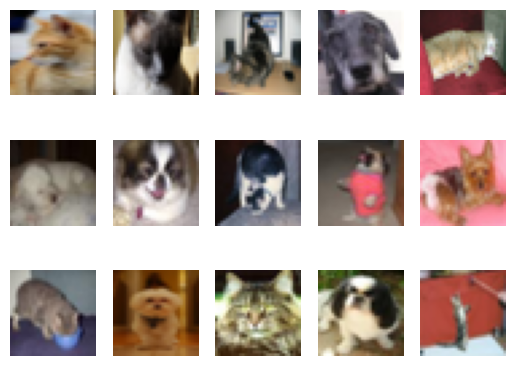

In [17]:
import matplotlib.pyplot as plt

k = 0
for images, labels in train_loader:
    # since batch_size = 1, there is only 1 image in `images`
    image = images[0]
    # place the colour channel at the end, instead of at the beginning
    img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
    img = img / 2 + 0.5
    plt.subplot(3, 5, k+1)
    plt.axis('off')
    plt.imshow(img)

    k += 1
    if k > 14:
        break

### Part (b) -- 3 pt

How many training examples do we have for the combined `cat` and `dog` classes? 
What about validation examples? 
What about test examples?

In [ ]:
print('There are',len(train_loader.dataset), 'training examples for the combined cat and dog classes.')
print('There are',len(val_loader.dataset), 'validation examples for the combined cat and dog classes.')
print('There are',len(test_loader.dataset), 'test examples for the combined cat and dog classes.')

There are 50000 training examples for the combined cat and dog classes.
There are 50000 validation examples for the combined cat and dog classes.
There are 10000 test examples for the combined cat and dog classes.


### Part (c) -- 3pt

Why do we need a validation set when training our model? What happens if we judge the 
performance of our models using the training set loss/error instead of the validation
set loss/error?

If a neural network trains for too many epochs, it can begin to memorize the training set resulting in a near 0 loss/error. However, that only reflects the model's ability to memorize data instead of it's ability to generalize it by identifying patterns. The purpose of the validation set is to provide the model with new data. If the validation set loss/error is high, that shows us that the model parameters need to be tweaked since it is not accurately generalizing unseen data.  

## Part 2. Training [15 pt]

We define two neural networks, a `LargeNet` and `SmallNet`.
We'll be training the networks in this section.

You won't understand fully what these networks are doing until
the next few classes, and that's okay. For this assignment, please
focus on learning how to train networks, and how hyperparameters affect
training.

In [ ]:
class LargeNet(nn.Module):
    def __init__(self):
        super(LargeNet, self).__init__()
        self.name = "large"
        self.conv1 = nn.Conv2d(3, 5, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5)
        self.fc1 = nn.Linear(10 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.name = "small"
        self.conv = nn.Conv2d(3, 5, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(5 * 7 * 7, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = self.pool(x)
        x = x.view(-1, 5 * 7 * 7)
        x = self.fc(x)
        x = x.squeeze(1) # Flatten to [batch_size]
        return x

In [ ]:
small_net = SmallNet()
large_net = LargeNet()

### Part (a) -- 2pt

The methods `small_net.parameters()` and `large_net.parameters()`
produces an iterator of all the trainable parameters of the network.
These parameters are torch tensors containing many scalar values. 

We haven't learned how how the parameters in these high-dimensional
tensors will be used, but we should be able to count the number
of parameters. Measuring the number of parameters in a network is
one way of measuring the "size" of a network.

What is the total number of parameters in `small_net` and in
`large_net`? (Hint: how many numbers are in each tensor?)

In [ ]:
smallParamsCount = 0
largeParamsCount = 0

for params in small_net.parameters():
  smallParamsCount += params.numel()

for params in large_net.parameters():
  largeParamsCount += params.numel()

print("Total number of paramaters in small_net:", int(smallParamsCount))
print("Total number of parameters in large_net:", int(largeParamsCount))

Total number of paramaters in small_net: 386
Total number of parameters in large_net: 9705


### The function train_net

The function `train_net` below takes an untrained neural network (like `small_net` and `large_net`) and
several other parameters. You should be able to understand how this function works.
The figure below shows the high level training loop for a machine learning model:

![alt text](https://github.com/UTNeural/Lab2/blob/master/Diagram.png?raw=true)

In [21]:
def train_net(net, batch_size=64, learning_rate=0.01, num_epochs=30):
    ########################################################################
    # Train a classifier on cats vs dogs
    target_classes = ["cat", "dog"]
    ########################################################################
    # Fixed PyTorch random seed for reproducible result
    torch.manual_seed(1000)
    ########################################################################
    # Obtain the PyTorch data loader objects to load batches of the datasets
    train_loader, val_loader, test_loader, classes = get_data_loader(
            target_classes, batch_size)
    ########################################################################
    # Define the Loss function and optimizer
    # The loss function will be Binary Cross Entropy (BCE). In this case we
    # will use the BCEWithLogitsLoss which takes unnormalized output from
    # the neural network and scalar label.
    # Optimizer will be SGD with Momentum.
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(net.parameters(), lr=learning_rate, momentum=0.9)
    ########################################################################
    # Set up some numpy arrays to store the training/test loss/erruracy
    train_err = np.zeros(num_epochs)
    train_loss = np.zeros(num_epochs)
    val_err = np.zeros(num_epochs)
    val_loss = np.zeros(num_epochs)
    ########################################################################
    # Train the network
    # Loop over the data iterator and sample a new batch of training data
    # Get the output from the network, and optimize our loss function.
    start_time = time.time()
    for epoch in range(num_epochs):  # loop over the dataset multiple times
        total_train_loss = 0.0
        total_train_err = 0.0
        total_epoch = 0
        for i, data in enumerate(train_loader, 0):
            # Get the inputs
            inputs, labels = data
            labels = normalize_label(labels) # Convert labels to 0/1
            # Zero the parameter gradients
            optimizer.zero_grad()
            # Forward pass, backward pass, and optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            # Calculate the statistics
            corr = (outputs > 0.0).squeeze().long() != labels
            total_train_err += int(corr.sum())
            total_train_loss += loss.item()
            total_epoch += len(labels)
        train_err[epoch] = float(total_train_err) / total_epoch
        train_loss[epoch] = float(total_train_loss) / (i+1)
        val_err[epoch], val_loss[epoch] = evaluate(net, val_loader, criterion)
        print(("Epoch {}: Train err: {}, Train loss: {} |"+
               "Validation err: {}, Validation loss: {}").format(
                   epoch + 1,
                   train_err[epoch],
                   train_loss[epoch],
                   val_err[epoch],
                   val_loss[epoch]))
        # Save the current model (checkpoint) to a file
        model_path = get_model_name(net.name, batch_size, learning_rate, epoch)
        torch.save(net.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_err)
    np.savetxt("{}_train_loss.csv".format(model_path), train_loss)
    np.savetxt("{}_val_err.csv".format(model_path), val_err)
    np.savetxt("{}_val_loss.csv".format(model_path), val_loss)

### Part (b) -- 1pt

The parameters to the function `train_net` are hyperparameters of our neural network.
We made these hyperparameters easy to modify so that we can tune them later on. 

What are the default values of the parameters `batch_size`, `learning_rate`, 
and `num_epochs`?

Default value of batch_size: 64


Default value of learning_rate: 0.01


Default value of num_epochs: 30

### Part (c) -- 3 pt

What files are written to disk when we call `train_net` with `small_net`, and train for 5 epochs? Provide a list
of all the files written to disk, and what information the files contain.

In [22]:
train_net(small_net, num_epochs=5)

Epoch 1: Train err: 0.43375, Train loss: 0.6764066801071167 |Validation err: 0.3925, Validation loss: 0.6581182591617107
Epoch 2: Train err: 0.369875, Train loss: 0.6494521961212159 |Validation err: 0.382, Validation loss: 0.6626495663076639
Epoch 3: Train err: 0.359375, Train loss: 0.6328314023017884 |Validation err: 0.3515, Validation loss: 0.628903878852725
Epoch 4: Train err: 0.338, Train loss: 0.6157211928367615 |Validation err: 0.36, Validation loss: 0.6280345916748047
Epoch 5: Train err: 0.323875, Train loss: 0.6042150614261628 |Validation err: 0.334, Validation loss: 0.6177018918097019
Finished Training
Total time elapsed: 31.35 seconds


1. model_small_bs64_lr0.01_epoch0 contains the model checkpoint for epoch 1
2. model_small_bs64_lr0.01_epoch1 contains the model checkpoint for epoch 2
3. model_small_bs64_lr0.01_epoch2 contains the model checkpoint for epoch 3
4. model_small_bs64_lr0.01_epoch3 contains the model checkpoint for epoch 4
5. model_small_bs64_lr0.01_epoch4 contains the model checkpoint for epoch 5
6. model_small_bs64_lr0.01_epoch4_train_err.csv contains the training error for each epoch
7. model_small_bs64_lr0.01_epoch4_train_loss.csv contains the training loss for each epoch
8. model_small_bs64_lr0.01_epoch4_val_err.csv contains the validation error for each epoch
9. model_small_bs64_lr0.01_epoch4_val_loss.csv contains the validation loss for each epoch

### Part (d) -- 2pt

Train both `small_net` and `large_net` using the function `train_net` and its default parameters.
The function will write many files to disk, including a model checkpoint (saved values of model weights) 
at the end of each epoch.

If you are using Google Colab, you will need to mount Google Drive 
so that the files generated by `train_net` gets saved. We will be using
these files in part (d).
(See the Google Colab tutorial for more information about this.)

Report the total time elapsed when training each network. Which network took longer to train?
Why?

In [ ]:
# Since the function writes files to disk, you will need to mount
# your Google Drive. If you are working on the lab locally, you
# can comment out this code.

"""from google.colab import drive
drive.mount('/content/gdrive')"""

"from google.colab import drive\ndrive.mount('/content/gdrive')"

In [ ]:
train_net(small_net)
train_net(large_net)

Epoch 1: Train err: 0.281625, Train loss: 0.5489379467964173 |Validation err: 0.3165, Validation loss: 0.5858508441597223
Epoch 2: Train err: 0.277375, Train loss: 0.547307788848877 |Validation err: 0.321, Validation loss: 0.598908469080925
Epoch 3: Train err: 0.28125, Train loss: 0.5506510996818542 |Validation err: 0.311, Validation loss: 0.5850378796458244
Epoch 4: Train err: 0.276125, Train loss: 0.5459364769458771 |Validation err: 0.3075, Validation loss: 0.5789202395826578
Epoch 5: Train err: 0.279, Train loss: 0.5447643954753876 |Validation err: 0.3015, Validation loss: 0.5861032959073782
Epoch 6: Train err: 0.278375, Train loss: 0.5417867505550384 |Validation err: 0.314, Validation loss: 0.5887431325390935
Epoch 7: Train err: 0.28, Train loss: 0.5434957826137543 |Validation err: 0.317, Validation loss: 0.5904063945636153
Epoch 8: Train err: 0.27525, Train loss: 0.5426751539707184 |Validation err: 0.31, Validation loss: 0.5858736289665103
Epoch 9: Train err: 0.27325, Train loss: 

small_net Total Time Elapsed: 181.77 seconds

large_net Total Time Elapsed: 183.29 seconds
 
large_net took longer to train due to having more parameters to tune.

### Part (e) - 2pt

Use the function `plot_training_curve` to display the trajectory of the 
training/validation error and the training/validation loss.
You will need to use the function `get_model_name` to generate the
argument to the `plot_training_curve` function.

Do this for both the small network and the large network. Include both plots
in your writeup.

small_net Model


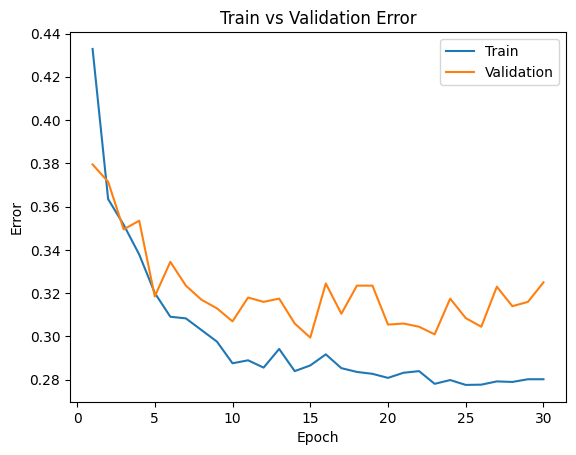

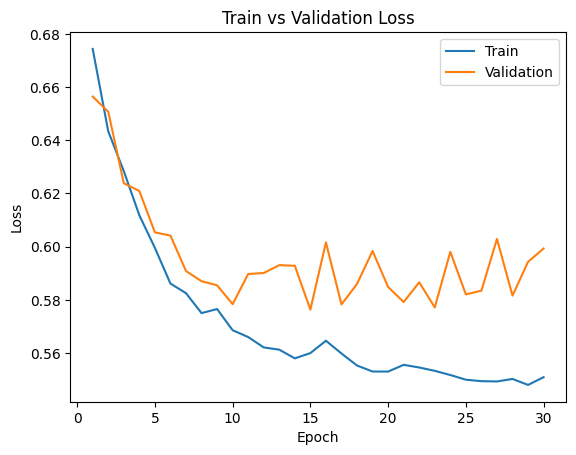

In [ ]:
#model_path = get_model_name("small", batch_size=??, learning_rate=??, epoch=29)
print("small_net Model")
model_path = get_model_name("small", batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

large_net Model


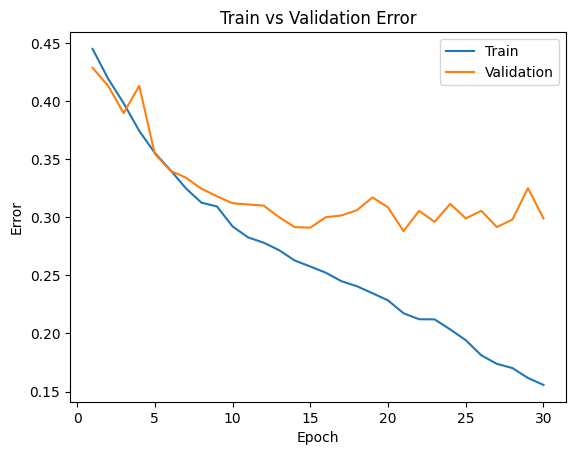

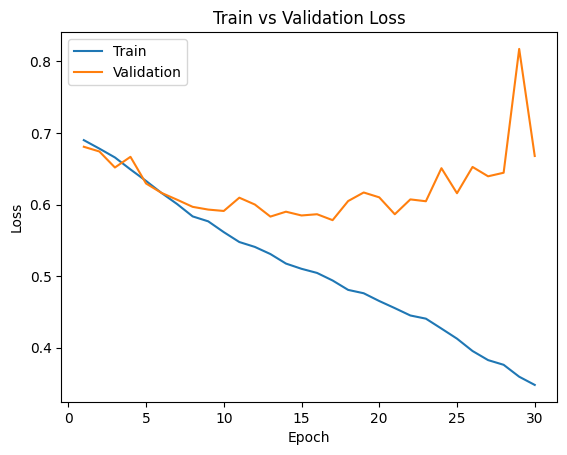

In [ ]:
print("large_net Model")
model_path = get_model_name("large", batch_size=64, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

### Part (f) - 5pt

Describe what you notice about the training curve.
How do the curves differ for `small_net` and `large_net`?
Identify any occurences of underfitting and overfitting.

During the first couple epochs, both the small_net and large_net models successfully learn from the training data, as shown by the consistent decrease in training and validation loss.

The small_net model remains stable and only begins to flatten near the end of the training run. This indicates that with the given epochs, the model is training steadily but training for significantly more epochs may eventually cause overfitting.

The large_net model begins to overfit quicker than the small_net model. Although the training error approaches zero, the validation loss starts to increase sharply, showing that the model begins to memorize the training data rather than learning the patterns. small_net is better for this dataset since it avoids overfitting and has a higher overall accuracy on unseen data.

## Part 3. Optimization Parameters [12 pt]

For this section, we will work with `large_net` only.

### Part (a) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.001`.
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *lowering* the learning rate.

Epoch 1: Train err: 0.47625, Train loss: 0.6928360028266907 |Validation err: 0.467, Validation loss: 0.6924686562269926
Epoch 2: Train err: 0.448625, Train loss: 0.6922589712142945 |Validation err: 0.4305, Validation loss: 0.6916493382304907
Epoch 3: Train err: 0.43575, Train loss: 0.6916067571640014 |Validation err: 0.4285, Validation loss: 0.6908544506877661
Epoch 4: Train err: 0.43, Train loss: 0.69086146068573 |Validation err: 0.425, Validation loss: 0.689660083502531
Epoch 5: Train err: 0.434375, Train loss: 0.6899197096824646 |Validation err: 0.4195, Validation loss: 0.6886945366859436
Epoch 6: Train err: 0.435875, Train loss: 0.6887416591644288 |Validation err: 0.4195, Validation loss: 0.6867828834801912
Epoch 7: Train err: 0.43675, Train loss: 0.6873776836395263 |Validation err: 0.4185, Validation loss: 0.6851986143738031
Epoch 8: Train err: 0.437375, Train loss: 0.6859259757995605 |Validation err: 0.4115, Validation loss: 0.6831978671252728
Epoch 9: Train err: 0.424625, Train 

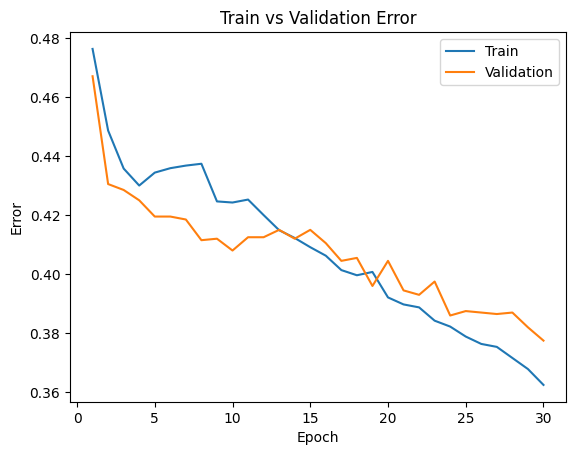

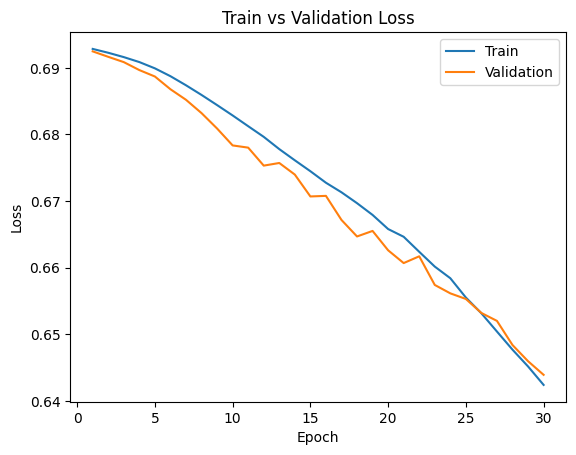

In [ ]:
# Note: When we re-construct the model, we start the training
# with *random weights*. If we omit this code, the values of
# the weights will still be the previously trained values.
large_net = LargeNet()
train_net(large_net, learning_rate=0.001)
model_path = get_model_name("large", batch_size=64, learning_rate=0.001, epoch=29)
plot_training_curve(model_path)

large_net Total Time Elapsed: 192.64 seconds

The model will take smaller steps when the learning rate is lowered to 0.001. This results in a more stable training process since the model smoothly descends the error curve without overshooting the optimal solution. Compared to the graph in Part 2(e) where the learning rate is higher, this graph has no sign of overfitting, meaning it successfully avoids memorizing the data and overfitting. The model took around the same time to train (slightly longer).

### Part (b) - 3pt

Train `large_net` with all default parameters, except set `learning_rate=0.1`. 
Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the learning rate.

Epoch 1: Train err: 0.429875, Train loss: 0.6752145900726318 |Validation err: 0.378, Validation loss: 0.6376289241015911
Epoch 2: Train err: 0.361, Train loss: 0.635660385131836 |Validation err: 0.3655, Validation loss: 0.6286003105342388
Epoch 3: Train err: 0.358, Train loss: 0.6286972823143006 |Validation err: 0.344, Validation loss: 0.6073819901794195
Epoch 4: Train err: 0.324875, Train loss: 0.599667014837265 |Validation err: 0.3345, Validation loss: 0.6175024146214128
Epoch 5: Train err: 0.312625, Train loss: 0.5853321487903596 |Validation err: 0.328, Validation loss: 0.5958995874971151
Epoch 6: Train err: 0.30475, Train loss: 0.5720449073314666 |Validation err: 0.317, Validation loss: 0.5965266218408942
Epoch 7: Train err: 0.287625, Train loss: 0.5497790281772613 |Validation err: 0.313, Validation loss: 0.589727558195591
Epoch 8: Train err: 0.28525, Train loss: 0.5494865167140961 |Validation err: 0.316, Validation loss: 0.6060120966285467
Epoch 9: Train err: 0.279375, Train loss:

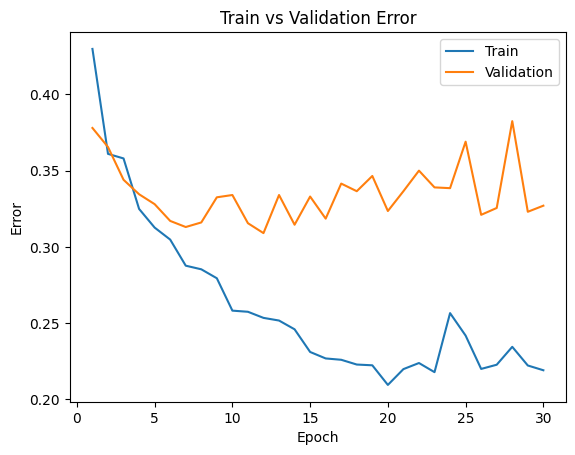

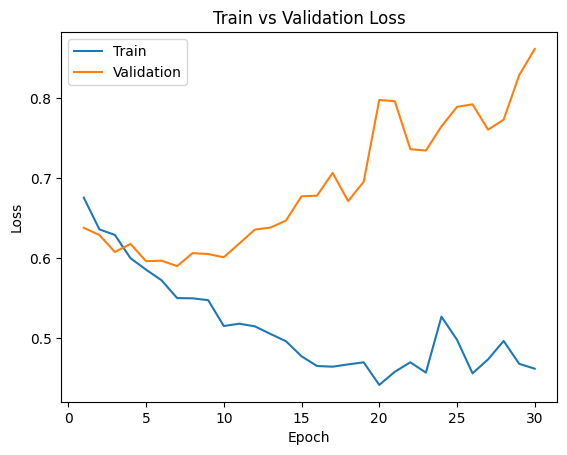

In [ ]:
large_net = LargeNet()
train_net(large_net, learning_rate=0.1)
model_path = get_model_name("large", batch_size=64, learning_rate=0.1, epoch=29)
plot_training_curve(model_path)

large_net Total Time Elapsed: 189.36 seconds

When the learning rate is increased, the model takes overly large steps that prevents it from smoothly descending the error curve. It overshoots the optimal solution and bounces back and forth. The model will train and memorize the most immediate data, causing it to perform perfectly on data it's seen before but poorly on new data since it did not properly learn pattern recognition. This causes overfitting, as reflected in the graph above. The training time was around the same. 

### Part (c) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=512`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *increasing* the batch size.

Epoch 1: Train err: 0.48175, Train loss: 0.6929379552602768 |Validation err: 0.478, Validation loss: 0.6926824003458023
Epoch 2: Train err: 0.457625, Train loss: 0.6924103945493698 |Validation err: 0.434, Validation loss: 0.6917425245046616
Epoch 3: Train err: 0.437, Train loss: 0.691650040447712 |Validation err: 0.4265, Validation loss: 0.6909129768610001
Epoch 4: Train err: 0.433625, Train loss: 0.6908450089395046 |Validation err: 0.424, Validation loss: 0.6897870898246765
Epoch 5: Train err: 0.434125, Train loss: 0.6896936446428299 |Validation err: 0.424, Validation loss: 0.6881358772516251
Epoch 6: Train err: 0.43825, Train loss: 0.6883534938097 |Validation err: 0.428, Validation loss: 0.6860135495662689
Epoch 7: Train err: 0.43925, Train loss: 0.6866876073181629 |Validation err: 0.426, Validation loss: 0.6836975812911987
Epoch 8: Train err: 0.435375, Train loss: 0.684977550059557 |Validation err: 0.412, Validation loss: 0.6814657151699066
Epoch 9: Train err: 0.42375, Train loss: 0

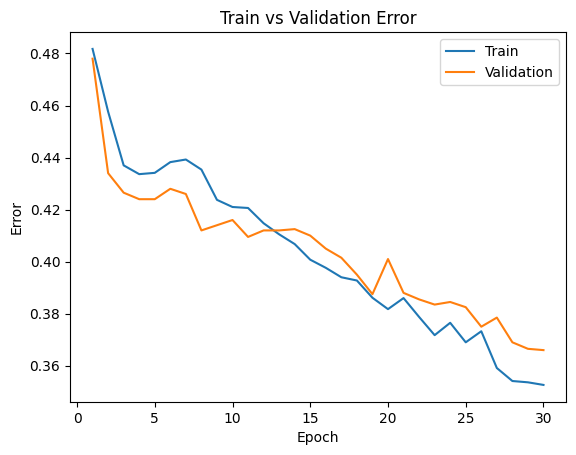

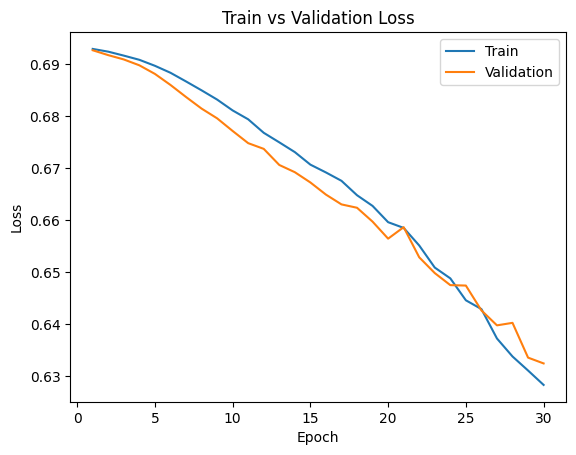

In [ ]:
large_net = LargeNet()
train_net(large_net, batch_size=512)
model_path = get_model_name("large", batch_size=512, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

large_net Total Time Elapsed: 183.07 seconds

Increasing the batch size gives the model more images to train from, and the model takes smaller or smoother steps. For this specific number of epoches, increasing the batch size improved the overfitting problem and the overall validation error. The training time was around the same. 

### Part (d) - 3pt

Train `large_net` with all default parameters, including with `learning_rate=0.01`.
Now, set `batch_size=16`. Does the model take longer/shorter to train?
Plot the training curve. Describe the effect of *decreasing* the batch size.

Epoch 1: Train err: 0.435875, Train loss: 0.6778940090537071 |Validation err: 0.365, Validation loss: 0.6485956735610962
Epoch 2: Train err: 0.368125, Train loss: 0.6430615016818046 |Validation err: 0.367, Validation loss: 0.6378458828926087
Epoch 3: Train err: 0.342625, Train loss: 0.6201045297980309 |Validation err: 0.3275, Validation loss: 0.6035718166828156
Epoch 4: Train err: 0.32225, Train loss: 0.5939668470621109 |Validation err: 0.319, Validation loss: 0.5922379739284516
Epoch 5: Train err: 0.306625, Train loss: 0.5695922685563565 |Validation err: 0.3135, Validation loss: 0.5893684346675873
Epoch 6: Train err: 0.28275, Train loss: 0.5503168917894363 |Validation err: 0.3, Validation loss: 0.5803121421337127
Epoch 7: Train err: 0.2775, Train loss: 0.5328537861704826 |Validation err: 0.302, Validation loss: 0.566103664636612
Epoch 8: Train err: 0.25625, Train loss: 0.5101081931591034 |Validation err: 0.289, Validation loss: 0.5616424233913422
Epoch 9: Train err: 0.250375, Train lo

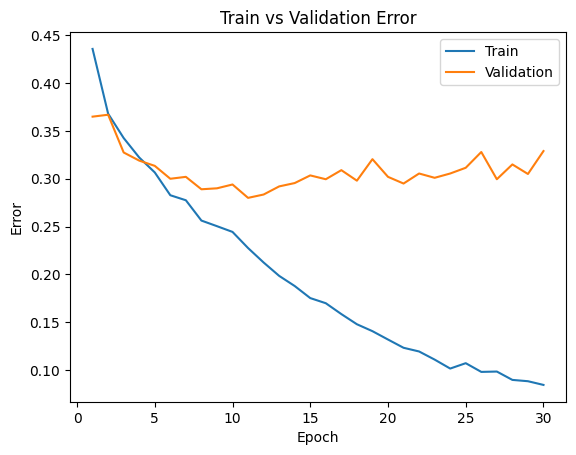

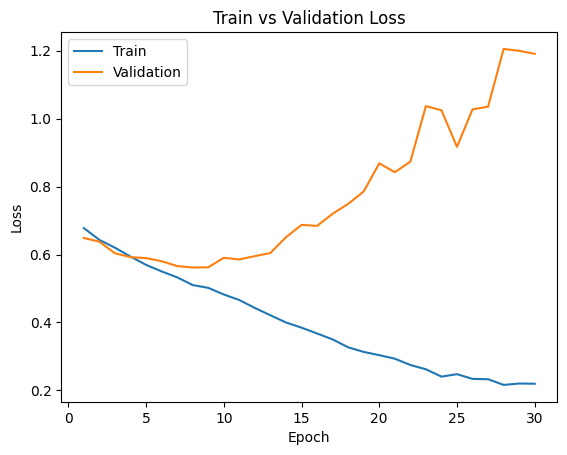

In [ ]:
large_net = LargeNet()
train_net(large_net, batch_size=16)
model_path = get_model_name("large", batch_size=16, learning_rate=0.01, epoch=29)
plot_training_curve(model_path)

large_net Total Time Elapsed: 183.07 seconds

The model looks at just a few images. However, a few images doesn't represent the entire dataset. The model takes large steps and instead of just overfitting, the instability of the model lead to divergence. The training time stayed relatively the same. 

## Part 4. Hyperparameter Search [6 pt]

### Part (a) - 2pt

Based on the plots from above, choose another set of values for the hyperparameters (network, batch_size, learning_rate)
that you think would help you improve the validation accuracy. Justify your choice.

Network: large_net -> The reason I chose large_net is because the extra paramaters allow the model to learn more complex and abstract features. With the right parameters, it will achieve better accuracy than small_net, since small_net is more limited.

batch_size: 256 -> From experiementing above, it is clear that a higher batch size can improve a model's validation loss. However, with more epochs a batch size that is too large can cause overfitting. For that reason, I chose a batch size that is larger but not by too much for balance.  

learning_rate: 0.001 -> As shown in the graphs above, a smaller learning rate can prevent overfitting or preventing the model from overshooting he optimal solution. A learning rate that is too low can cause the training time to increase too much, so 0.001 should avoid that risk. 

### Part (b) - 1pt

Train the model with the hyperparameters you chose in part(a), and include the training curve.

Epoch 1: Train err: 0.503875, Train loss: 0.6932193227112293 |Validation err: 0.5075, Validation loss: 0.6937714368104935
Epoch 2: Train err: 0.502875, Train loss: 0.6928257420659065 |Validation err: 0.508, Validation loss: 0.693457618355751
Epoch 3: Train err: 0.501125, Train loss: 0.6926502007991076 |Validation err: 0.504, Validation loss: 0.6933558508753777
Epoch 4: Train err: 0.501125, Train loss: 0.6924096755683422 |Validation err: 0.4975, Validation loss: 0.6931997686624527
Epoch 5: Train err: 0.498125, Train loss: 0.6920348685234785 |Validation err: 0.4925, Validation loss: 0.6929017752408981
Epoch 6: Train err: 0.498625, Train loss: 0.692049877718091 |Validation err: 0.4915, Validation loss: 0.6926217973232269
Epoch 7: Train err: 0.492875, Train loss: 0.6917557809501886 |Validation err: 0.4825, Validation loss: 0.6925594359636307
Epoch 8: Train err: 0.488375, Train loss: 0.6915176622569561 |Validation err: 0.478, Validation loss: 0.6922101154923439
Epoch 9: Train err: 0.488375,

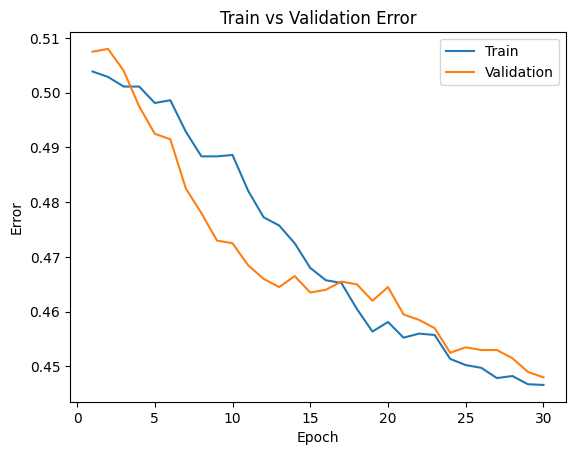

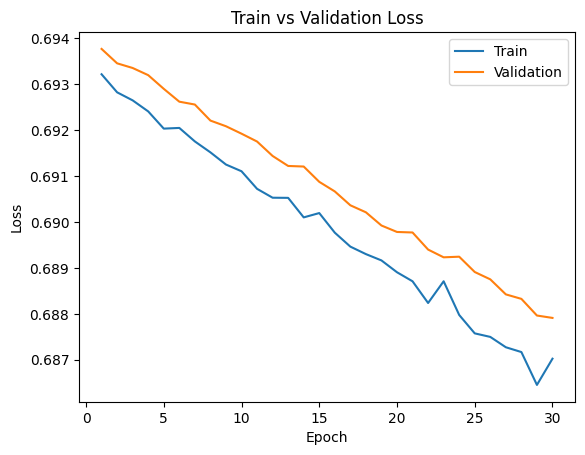

In [23]:
large_net = LargeNet()
train_net(large_net, batch_size = 256, learning_rate = 0.001)
my_model_path = get_model_name("large", batch_size = 256, learning_rate = 0.001, epoch = 29)
plot_training_curve(my_model_path)

### Part (c) - 2pt

Based on your result from Part(a), suggest another set of hyperparameter values to try. 
Justify your choice.

Network: large_net -> The reason I chose large_net is because the extra paramaters allow the model to learn more complex and abstract features. With the right parameters, it will achieve better accuracy than small_net, since small_net is more limited.

batch_size: 256 -> I have decided to keep the batch size the same since increasing it is a good idea, and 256 is not too high where there is a risk of eventually overfitting. 

learning_rate: 0.005 -> 0.001 might be too slow and need more epoches to converge. Trying a slightly higher rate might be a good middle group and more suitable for only 29 epoches. 

### Part (d) - 1pt

Train the model with the hyperparameters you chose in part(c), and include the training curve.

Epoch 1: Train err: 0.50225, Train loss: 0.6944286711513996 |Validation err: 0.491, Validation loss: 0.6913653463125229
Epoch 2: Train err: 0.500375, Train loss: 0.6920777093619108 |Validation err: 0.486, Validation loss: 0.6900237947702408
Epoch 3: Train err: 0.451125, Train loss: 0.6903787907212973 |Validation err: 0.422, Validation loss: 0.6884360611438751
Epoch 4: Train err: 0.4345, Train loss: 0.6883059199899435 |Validation err: 0.4105, Validation loss: 0.6858571618795395
Epoch 5: Train err: 0.43275, Train loss: 0.6857468653470278 |Validation err: 0.41, Validation loss: 0.6824368014931679
Epoch 6: Train err: 0.430625, Train loss: 0.6828877087682486 |Validation err: 0.412, Validation loss: 0.6786279529333115
Epoch 7: Train err: 0.42475, Train loss: 0.6792307142168283 |Validation err: 0.4145, Validation loss: 0.6748282238841057
Epoch 8: Train err: 0.413875, Train loss: 0.6759041100740433 |Validation err: 0.4175, Validation loss: 0.6731234341859818
Epoch 9: Train err: 0.405625, Train

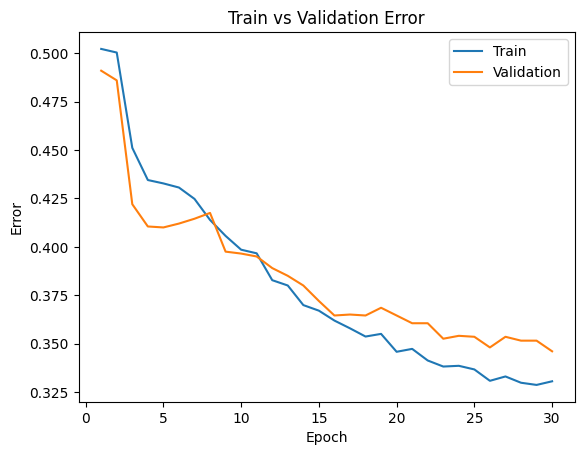

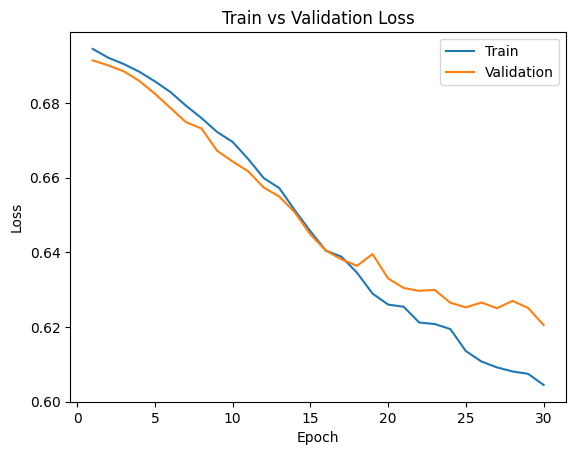

In [31]:
large_net = LargeNet()
train_net(large_net, batch_size = 256, learning_rate = 0.005)
my_model_path = get_model_name("large", batch_size = 256, learning_rate = 0.005  , epoch = 29)
plot_training_curve(my_model_path)

## Part 4. Evaluating the Best Model [15 pt]


### Part (a) - 1pt

Choose the **best** model that you have so far. This means choosing the best model checkpoint,
including the choice of `small_net` vs `large_net`, the `batch_size`, `learning_rate`, 
**and the epoch number**.

Modify the code below to load your chosen set of weights to the model object `net`.

In [29]:
net = LargeNet()
model_path = get_model_name(net.name, batch_size=256, learning_rate=0.005, epoch=29)
state = torch.load(model_path)
net.load_state_dict(state)

<All keys matched successfully>

### Part (b) - 2pt

Justify your choice of model from part (a).

Without adjusting parameters, small_net has less error. However, through adjusting parameters, large_net is able to achieve better results and be able to handle more complex problems making it the better choice. 

A learning rate of 0.005 was selected since for the training stability and balance. As observed in earlier experiments, a learning rate that is too high causes rapid overfitting, while a learning rate that is too low requires more epochs to converge. At 0.005, the model's loss curve descends smoothly delaying the training time and avoids overfitting.

When selecting the batch size, a value of 256 was chosen to balance between efficiency and stability. Smaller batch sizes can cause too much noise, causing the validation error to become unstable. Excessively large batch sizes can trap the model in sharp local minima. A batch size of 256 provides a smooth, consistent descent down the error curve while ensuring the model generalizes well to unseen data. 

### Part (c) - 2pt

Using the code in Part 0, any code from lecture notes, or any code that you write,
compute and report the **test classification error** for your chosen model.

In [30]:
# If you use the `evaluate` function provided in part 0, you will need to 
# set batch_size > 1
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"], 
    batch_size=256)
criterion = nn.BCEWithLogitsLoss()
error, loss = evaluate(net, test_loader, criterion)
print("The test classification error is", error)
print("The test classification loss is", loss)

The test classification error is 0.3565
The test classification loss is 0.6294687762856483


### Part (d) - 3pt

How does the test classification error compare with the **validation error**?
Explain why you would expect the test error to be *higher* than the validation error.

The test error (0.3565) is slightly higher than the validation error (0.346). This is expected because the model has seen the validation dataset many times while training and adjusting parameters, so its prediction will be slightly more accurate for the validation data. For the test data, the model has only been shown it once, so it will have more error and slightly less accurate predictions.

### Part (e) - 2pt

Why did we only use the test data set at the very end?
Why is it important that we use the test data as little as possible?

The test data should be used to test the model's accuracy when presented with new and unseen data. The test data should be shown to the model as little as possible so that  the accuracy of the model reflects what would be achieved in a real world scenario. If the model is shown a set of data too many times, the model might start memorizing the answers resulting in a biased accuracy. 

### Part (f) - 5pt

How does the your best CNN model compare with an 2-layer ANN model (no convolutional layers) on classifying cat and dog images. You can use a 2-layer ANN architecture similar to what you used in Lab 1. You should explore different hyperparameter settings to determine how well you can do on the validation dataset. Once satisified with the performance, you may test it out on the test data.

Hint: The ANN in lab 1 was applied on greyscale images. The cat and dog images are colour (RGB) and so you will need to flatted and concatinate all three colour layers before feeding them into an ANN.

c:\Users\sissi\OneDrive\Desktop\Code\APS360\APS360\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1: Train err: 0.487125, Train loss: 0.6926018204540014 |Validation err: 0.463, Validation loss: 0.6836823746562004
Epoch 2: Train err: 0.432625, Train loss: 0.680026488378644 |Validation err: 0.4405, Validation loss: 0.6750891208648682
Epoch 3: Train err: 0.411875, Train loss: 0.6729287542402744 |Validation err: 0.419, Validation loss: 0.6708412393927574
Epoch 4: Train err: 0.407875, Train loss: 0.6678786613047123 |Validation err: 0.4175, Validation loss: 0.6678296774625778
Epoch 5: Train err: 0.401, Train loss: 0.6644391361624002 |Validation err: 0.4165, Validation loss: 0.6656033471226692
Epoch 6: Train err: 0.398375, Train loss: 0.6629491858184338 |Validation err: 0.411, Validation loss: 0.6645127162337303
Epoch 7: Train err: 0.395, Train loss: 0.6603617798537016 |Validation err: 0.4055, Validation loss: 0.6631141155958176
Epoch 8: Train err: 0.39125, Train loss: 0.6584792155772448 |Validation err: 0.4035, Validation loss: 0.6618291065096855
Epoch 9: Train err: 0.39125, Train 

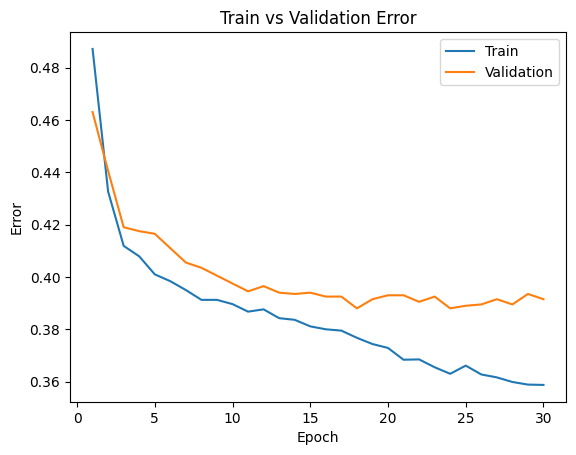

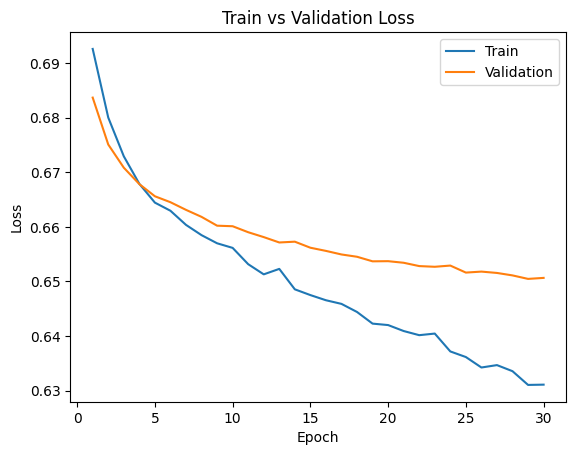

In [43]:
class Pigeon(nn.Module):
    def __init__(self):
        super(Pigeon, self).__init__()
        self.name = "pigeon"
        self.layer1 = nn.Linear(32 * 32 * 3, 30)
        self.layer2 = nn.Linear(30, 1)
    def forward(self, img):
        flattened = img.view(-1, 32 * 32 * 3)
        activation1 = self.layer1(flattened)
        activation1 = F.relu(activation1)
        activation2 = self.layer2(activation1)
        activation2 = activation2.squeeze(1)
        return activation2

pigeon = Pigeon()
train_net(pigeon, batch_size=256, learning_rate=0.001)
model_path = get_model_name("pigeon", batch_size=256, learning_rate=0.001, epoch=29)
plot_training_curve(model_path)

In [45]:
train_loader, val_loader, test_loader, classes = get_data_loader(
    target_classes=["cat", "dog"], 
    batch_size=256)
criterion = nn.BCEWithLogitsLoss()
error, loss = evaluate(pigeon, test_loader, criterion)
print("The test classification error is", error)
print("The test classification loss is", loss)

The test classification error is 0.375
The test classification loss is 0.6461758017539978


ANN cannot capture as many distinguishing features as CNN, causing the test accuracy to be lower. This is reflected in the test classification errors, where CNN had a lower test classification error than ANN. 